<div style="display:block;width:100%;margin:auto;" direction=rtl align=center><br><br>
    <div  style="width:100%;margin:100;display:block;background-color:#fff0;"  display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">             <tr>
                <td  style="border: none!important;">
                    <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>Armin Ghasemi</b><br><br>810100198</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b> DGM </b><br><br>HW1_Q2</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>  </b><br><br></i></font></h1>
                </td>
                <td style="border: none!important;">
                    <img width=170 align=left  src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
           </tr>
        </table>
    </div>
</div>


# CycleGAN for Unpaired Image-to-Image Translation

This project implements a **CycleGAN** model for unpaired image-to-image translation.

Unlike paired image-to-image translation methods, CycleGAN does not require corresponding images between the two domains. Instead, it learns two mappings between the domains and uses cycle consistency to preserve the content of the original images.

The main experiment in this notebook uses the **Horse2Zebra** dataset, where the model learns to translate between horse and zebra images. A second experiment on **Monet2Photo** is later used to investigate the effects of identity loss and a replay buffer on the training process.


## 1. Horse2Zebra Dataset

The first experiment uses the **Horse2Zebra** dataset, which contains two unpaired image domains:

* **Domain A:** Horses
* **Domain B:** Zebras

The dataset does not provide one-to-one correspondences between horses and zebras. Therefore, the model must learn the translation between the two visual domains without relying on paired examples.

The following cell downloads the dataset, extracts it, and visualizes random samples from both domains.


for details.

--2025-11-27 15:59:38--  https://efrosgans.eecs.berkeley.edu/cyclegan/datasets/horse2zebra.zip
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 116867962 (111M) [application/zip]
Saving to: ‘horse2zebra.zip’

horse2zebra.zip     100%[===================>] 111.45M  33.4MB/s    in 3.4s    

2025-11-27 15:59:42 (32.6 MB/s) - ‘horse2zebra.zip’ saved [116867962/116867962]

Extracting horse2zebra.zip...
Extraction complete.
------------------------------
Visualizing Domain A: Horses


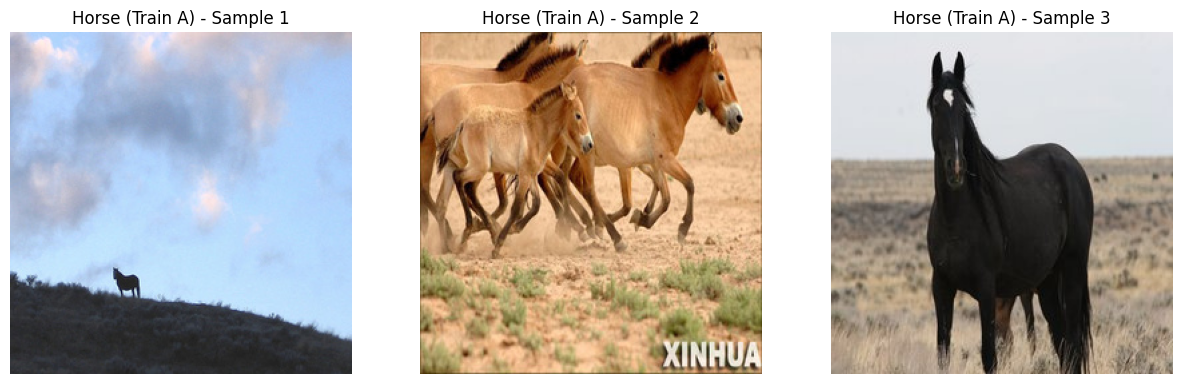

------------------------------
Visualizing Domain B: Zebras


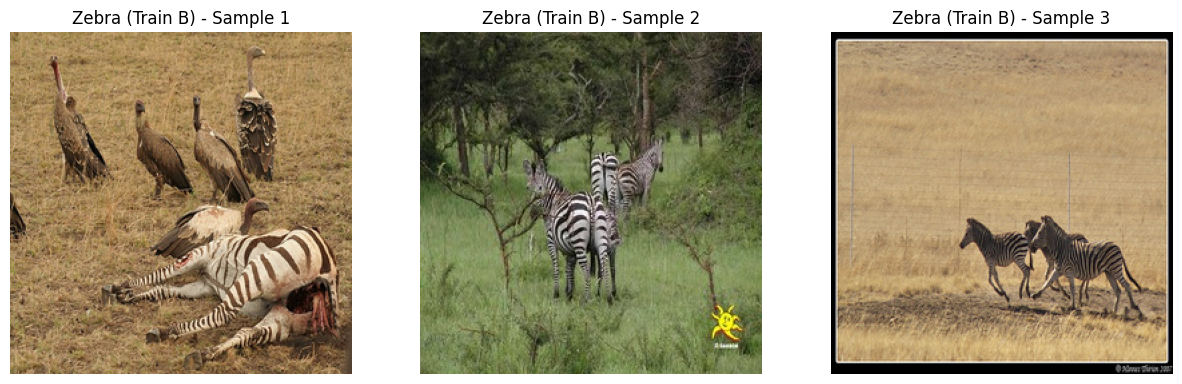

In [ ]:
import os
import zipfile
import random
import matplotlib.pyplot as plt
from PIL import Image

# 1. Download the dataset using the updated URL
dataset_url = "https://efrosgans.eecs.berkeley.edu/cyclegan/datasets/horse2zebra.zip"
zip_filename = "horse2zebra.zip"

print(f"Downloading {zip_filename} from {dataset_url}...")
# -O forces the output filename to be horse2zebra.zip
!wget -N {dataset_url} -O {zip_filename}

# 2. Unzip the dataset
# The dataset usually unzips into a folder named 'horse2zebra'
if not os.path.exists("horse2zebra"):
    print(f"Extracting {zip_filename}...")
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Extraction complete.")
else:
    print("Dataset folder already exists. Skipping extraction.")

# 3. Setup directory paths
base_path = "horse2zebra"
train_a_path = os.path.join(base_path, "trainA")
train_b_path = os.path.join(base_path, "trainB")

# Verify directories exist
if not os.path.exists(train_a_path) or not os.path.exists(train_b_path):
    print(f"Error: Could not find trainA or trainB inside {base_path}")
    print(f"Contents of {base_path}: {os.listdir(base_path)}")
else:
    # 4. Function to visualize random samples
    def visualize_samples(directory_path, domain_name, num_samples=3):
        all_files = os.listdir(directory_path)
        image_files = [f for f in all_files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if len(image_files) < num_samples:
            print(f"Not enough images in {domain_name} to sample {num_samples}.")
            return

        selected_files = random.sample(image_files, num_samples)

        plt.figure(figsize=(15, 5))
        for i, file_name in enumerate(selected_files):
            img_path = os.path.join(directory_path, file_name)
            img = Image.open(img_path)

            plt.subplot(1, num_samples, i + 1)
            plt.imshow(img)
            plt.title(f"{domain_name} - Sample {i+1}")
            plt.axis("off")
        plt.show()

    # 5. Display images
    print("-" * 30)
    print("Visualizing Domain A: Horses")
    visualize_samples(train_a_path, "Horse (Train A)")

    print("-" * 30)
    print("Visualizing Domain B: Zebras")
    visualize_samples(train_b_path, "Zebra (Train B)")

## 2. CycleGAN Architecture

CycleGAN uses two generators and two discriminators to learn bidirectional translation between the two domains.

For the Horse2Zebra experiment, the two mappings are:

$$
G_{AB}: \text{Horse} \rightarrow \text{Zebra}
$$

$$
G_{BA}: \text{Zebra} \rightarrow \text{Horse}
$$

The corresponding discriminators are:

$$
D_A: \text{Horse} \rightarrow \text{Real/Fake}
$$

$$
D_B: \text{Zebra} \rightarrow \text{Real/Fake}
$$

The two generators allow the model to learn both translation directions, while the discriminators encourage the generated images to match the visual characteristics of their target domains.


### 2.1 Generator Architecture

Each generator follows a convolutional encoder-decoder architecture with residual blocks.

The architecture consists of:

1. An initial convolutional layer with reflection padding
2. Two downsampling layers
3. A sequence of residual blocks
4. Two upsampling layers
5. A final convolutional layer with Tanh activation

The implementation uses **6 residual blocks**.

The residual blocks use skip connections to facilitate the learning of transformations while preserving useful information from the input.

Reflection padding is used to reduce boundary artifacts, and Instance Normalization is applied within the generator.


### 2.2 Discriminator Architecture

Each domain has a separate discriminator.

The discriminator for domain A distinguishes real horse images from generated horse images, while the discriminator for domain B distinguishes real zebra images from generated zebra images.

The model uses a **70 × 70 PatchGAN** discriminator. Instead of assigning a single real/fake label to the entire image, the discriminator evaluates local image patches.

This allows the discriminator to focus on local structures and textures that are important for realistic image translation.


In [1]:
import torch
import torch.nn as nn
from torchsummary import summary

# Install torchsummary if not already available in Colab
try:
    from torchsummary import summary
except ImportError:
    !pip install torchsummary
    from torchsummary import summary

# ----------------------------------------
# 1. Weight Initialization
# According to Appendix 7.1[cite: 562]: Weights are initialized from a Gaussian distribution N(0, 0.02).
# ----------------------------------------
def weights_init_normal(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        torch.nn.init.normal_(m.weight.data, 0.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            torch.nn.init.constant_(m.bias.data, 0.0)
    elif classname.find("BatchNorm2d") != -1 or classname.find("InstanceNorm2d") != -1:
        # Validating weight existence to avoid AttributeError
        if m.weight is not None:
            torch.nn.init.normal_(m.weight.data, 1.0, 0.02)
        if m.bias is not None:
            torch.nn.init.constant_(m.bias.data, 0.0)

# ----------------------------------------
# 2. Residual Block
# Based on[cite: 592]: Two 3x3 convolutional layers with same number of filters.
# ----------------------------------------
class ResidualBlock(nn.Module):
    def __init__(self, in_features):
        super(ResidualBlock, self).__init__()

        self.block = nn.Sequential(
            # Reflection padding reduces artifacts [cite: 591]
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_features, in_features, 3),
            nn.InstanceNorm2d(in_features),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_features, in_features, 3),
            nn.InstanceNorm2d(in_features),
        )

    def forward(self, x):
        return x + self.block(x)

# ----------------------------------------
# 3. Generator Architecture
# Based on Johnson et al. architecture described in Appendix 7.2 [cite: 588, 594]
# ----------------------------------------
class Generator(nn.Module):
    def __init__(self, input_shape, num_residual_blocks=6):
        super(Generator, self).__init__()

        channels = input_shape[0]

        # Initial Convolution Block: c7s1-64
        model = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(channels, 64, 7),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True),
        ]

        # Downsampling: d128, d256
        in_features = 64
        out_features = in_features * 2
        for _ in range(2):
            model += [
                nn.Conv2d(in_features, out_features, 3, stride=2, padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True),
            ]
            in_features = out_features
            out_features = in_features * 2

        # Residual Blocks: R256
        # Using 6 blocks for 128x128 images [cite: 181]
        for _ in range(num_residual_blocks):
            model += [ResidualBlock(in_features)]

        # Upsampling: u128, u64
        out_features = in_features // 2
        for _ in range(2):
            model += [
                nn.ConvTranspose2d(in_features, out_features, 3, stride=2, padding=1, output_padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True),
            ]
            in_features = out_features
            out_features = in_features // 2

        # Output Layer: c7s1-3
        model += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(64, channels, 7),
            nn.Tanh(),
        ]

        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)

# ----------------------------------------
# 4. Discriminator Architecture
# Based on 70x70 PatchGAN described in Appendix 7.2 [cite: 596, 599]
# ----------------------------------------
class Discriminator(nn.Module):
    def __init__(self, input_shape):
        super(Discriminator, self).__init__()

        channels, height, width = input_shape

        def discriminator_block(in_filters, out_filters, normalize=True):
            """Returns layers of each discriminator block"""
            layers = [nn.Conv2d(in_filters, out_filters, 4, stride=2, padding=1)]
            if normalize:
                # Instance normalization [cite: 597]
                layers.append(nn.InstanceNorm2d(out_filters))
            # Leaky ReLU with slope 0.2 [cite: 598]
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            # C64: No InstanceNorm for the first layer [cite: 598]
            *discriminator_block(channels, 64, normalize=False),
            # C128
            *discriminator_block(64, 128),
            # C256
            *discriminator_block(128, 256),
            # C512
            *discriminator_block(256, 512),
            # Final convolution to produce 1-dimensional output (Patch predictions)
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(512, 1, 4, padding=1)
        )

    def forward(self, img):
        return self.model(img)

# ----------------------------------------
# 5. Initialization and Summary
# ----------------------------------------

# Define input shape for 128x128 images
input_shape = (3, 128, 128)

# Initialize Generator and Discriminator
# Note: In CycleGAN we need two of each (G_AB, G_BA, D_A, D_B),
# but here we inspect one instance of each architecture.
G_sample = Generator(input_shape, num_residual_blocks=6)
D_sample = Discriminator(input_shape)

# Apply weights
G_sample.apply(weights_init_normal)
D_sample.apply(weights_init_normal)

# Move to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
G_sample.to(device)
D_sample.to(device)

print("="*60)
print(f"GENERATOR SUMMARY (6 ResBlocks, Input: {input_shape})")
print("Structure based on Johnson et al. [cite: 178]")
print("="*60)
summary(G_sample, input_shape)

print("\n")
print("="*60)
print(f"DISCRIMINATOR SUMMARY (70x70 PatchGAN, Input: {input_shape})")
print("Structure based on Isola et al. [cite: 183]")
print("="*60)
summary(D_sample, input_shape)

GENERATOR SUMMARY (6 ResBlocks, Input: (3, 128, 128))
Structure based on Johnson et al. [cite: 178]
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
   ReflectionPad2d-1          [-1, 3, 134, 134]               0
            Conv2d-2         [-1, 64, 128, 128]           9,472
    InstanceNorm2d-3         [-1, 64, 128, 128]               0
              ReLU-4         [-1, 64, 128, 128]               0
            Conv2d-5          [-1, 128, 64, 64]          73,856
    InstanceNorm2d-6          [-1, 128, 64, 64]               0
              ReLU-7          [-1, 128, 64, 64]               0
            Conv2d-8          [-1, 256, 32, 32]         295,168
    InstanceNorm2d-9          [-1, 256, 32, 32]               0
             ReLU-10          [-1, 256, 32, 32]               0
  ReflectionPad2d-11          [-1, 256, 34, 34]               0
           Conv2d-12          [-1, 256, 32, 32]         590,080
   

## 3. Data Pipeline

The two domains are loaded independently because the dataset is unpaired.

For each training step, the data loader provides one image from domain A and one image from domain B. These images do not need to correspond to each other.

All images are converted to RGB and resized to **128 × 128** pixels.

For training, random horizontal flipping is applied before converting the images to tensors. The images are then normalized using a mean and standard deviation of 0.5 for each RGB channel.

The main Horse2Zebra experiment uses a batch size of **1**, which is commonly used for CycleGAN training.


## 4. Training Objective

CycleGAN combines adversarial learning with cycle consistency.

### 4.1 Adversarial Loss

The adversarial loss encourages each generator to produce images that the discriminator classifies as belonging to the target domain.

In this implementation, the adversarial objective uses **Mean Squared Error (MSE)** loss.

### 4.2 Cycle-Consistency Loss

Cycle consistency ensures that translating an image to the other domain and then translating it back approximately reconstructs the original image.

For a horse image \(x\):

$$
G_{BA}(G_{AB}(x)) \approx x
$$

For a zebra image \(y\):

$$
G_{AB}(G_{BA}(y)) \approx y
$$

The cycle-consistency loss is computed using the L1 distance between the original and reconstructed images.

The total generator objective in the main experiment combines the two adversarial losses with the cycle-consistency loss:

$$
\mathcal{L}_G =
\mathcal{L}_{GAN}^{AB}
+
\mathcal{L}_{GAN}^{BA}
+
\lambda_{cyc}\mathcal{L}_{cycle}
$$

with:

$$
\lambda_{cyc}=10
$$

Identity loss is not included in this first training experiment; it is investigated separately in the second experiment.


## 5. Main Horse2Zebra Training

The CycleGAN model is first trained on the **Horse2Zebra** dataset using the basic training configuration.

The training process alternates between updating the two generators and the two discriminators.

For each batch:

1. The generators produce fake images in both directions.
2. The adversarial losses are computed for both generators.
3. The generated images are translated back to their original domains.
4. The cycle-consistency loss is computed.
5. The two generators are updated.
6. Each discriminator is updated using real and generated images.

The model is trained for **30 epochs** with a learning rate of **0.0002** and Adam optimizers using \(\beta_1=0.5\) and \(\beta_2=0.999\).


Starting training for 30 epochs on cuda...
[Epoch 1/30] [G loss: 2.8861] [Cycle: 0.2419]
[Epoch 2/30] [G loss: 3.3666] [Cycle: 0.2138]
[Epoch 3/30] [G loss: 2.7944] [Cycle: 0.1962]
[Epoch 4/30] [G loss: 3.0181] [Cycle: 0.2383]
[Epoch 5/30] [G loss: 2.7348] [Cycle: 0.1984]
[Epoch 6/30] [G loss: 2.7563] [Cycle: 0.2108]
[Epoch 7/30] [G loss: 3.5186] [Cycle: 0.2834]
[Epoch 8/30] [G loss: 2.7810] [Cycle: 0.1635]
[Epoch 9/30] [G loss: 2.6729] [Cycle: 0.1830]
[Epoch 10/30] [G loss: 3.1664] [Cycle: 0.2359]

--- Samples at Epoch 10 ---


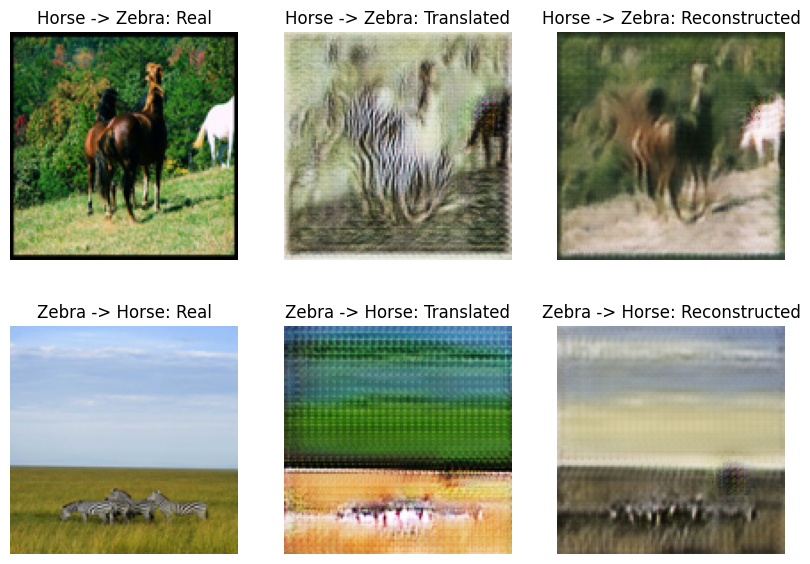

[Epoch 11/30] [G loss: 3.0464] [Cycle: 0.2170]
[Epoch 12/30] [G loss: 2.9283] [Cycle: 0.1943]
[Epoch 13/30] [G loss: 3.2551] [Cycle: 0.1754]
[Epoch 14/30] [G loss: 3.0608] [Cycle: 0.2220]
[Epoch 15/30] [G loss: 3.1451] [Cycle: 0.1927]
[Epoch 16/30] [G loss: 2.7176] [Cycle: 0.1449]
[Epoch 17/30] [G loss: 3.2896] [Cycle: 0.1915]
[Epoch 18/30] [G loss: 3.1888] [Cycle: 0.1599]
[Epoch 19/30] [G loss: 3.7366] [Cycle: 0.2453]
[Epoch 20/30] [G loss: 3.1237] [Cycle: 0.2069]

--- Samples at Epoch 20 ---


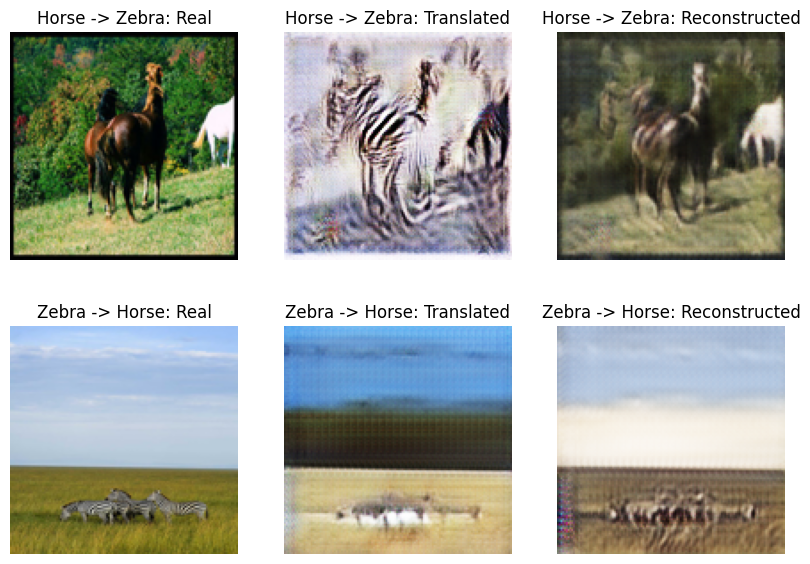

[Epoch 21/30] [G loss: 3.3308] [Cycle: 0.1509]
[Epoch 22/30] [G loss: 2.1590] [Cycle: 0.1505]
[Epoch 23/30] [G loss: 2.2633] [Cycle: 0.1425]
[Epoch 24/30] [G loss: 2.1963] [Cycle: 0.1382]
[Epoch 25/30] [G loss: 2.6029] [Cycle: 0.1741]
[Epoch 26/30] [G loss: 3.1607] [Cycle: 0.1974]
[Epoch 27/30] [G loss: 2.6195] [Cycle: 0.1583]
[Epoch 28/30] [G loss: 2.3754] [Cycle: 0.1749]
[Epoch 29/30] [G loss: 2.5032] [Cycle: 0.1586]
[Epoch 30/30] [G loss: 2.5606] [Cycle: 0.1496]

--- Samples at Epoch 30 ---


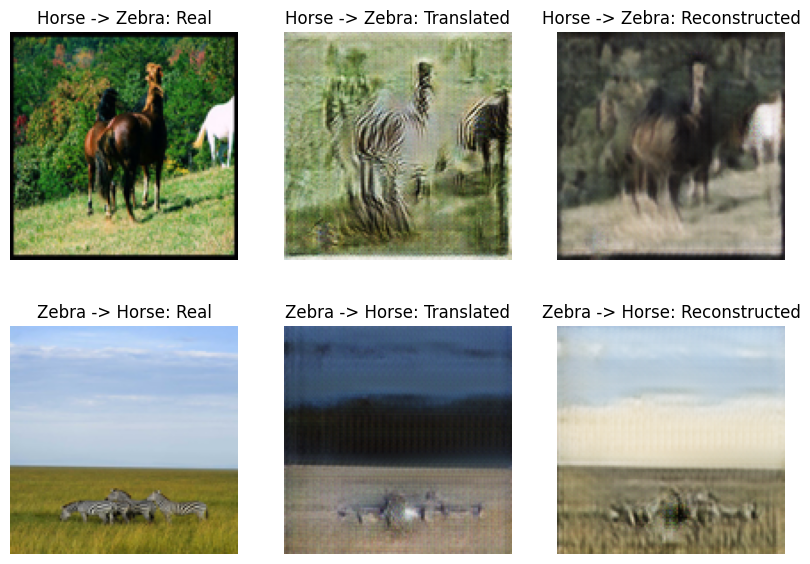

Training finished in 59.4 minutes.


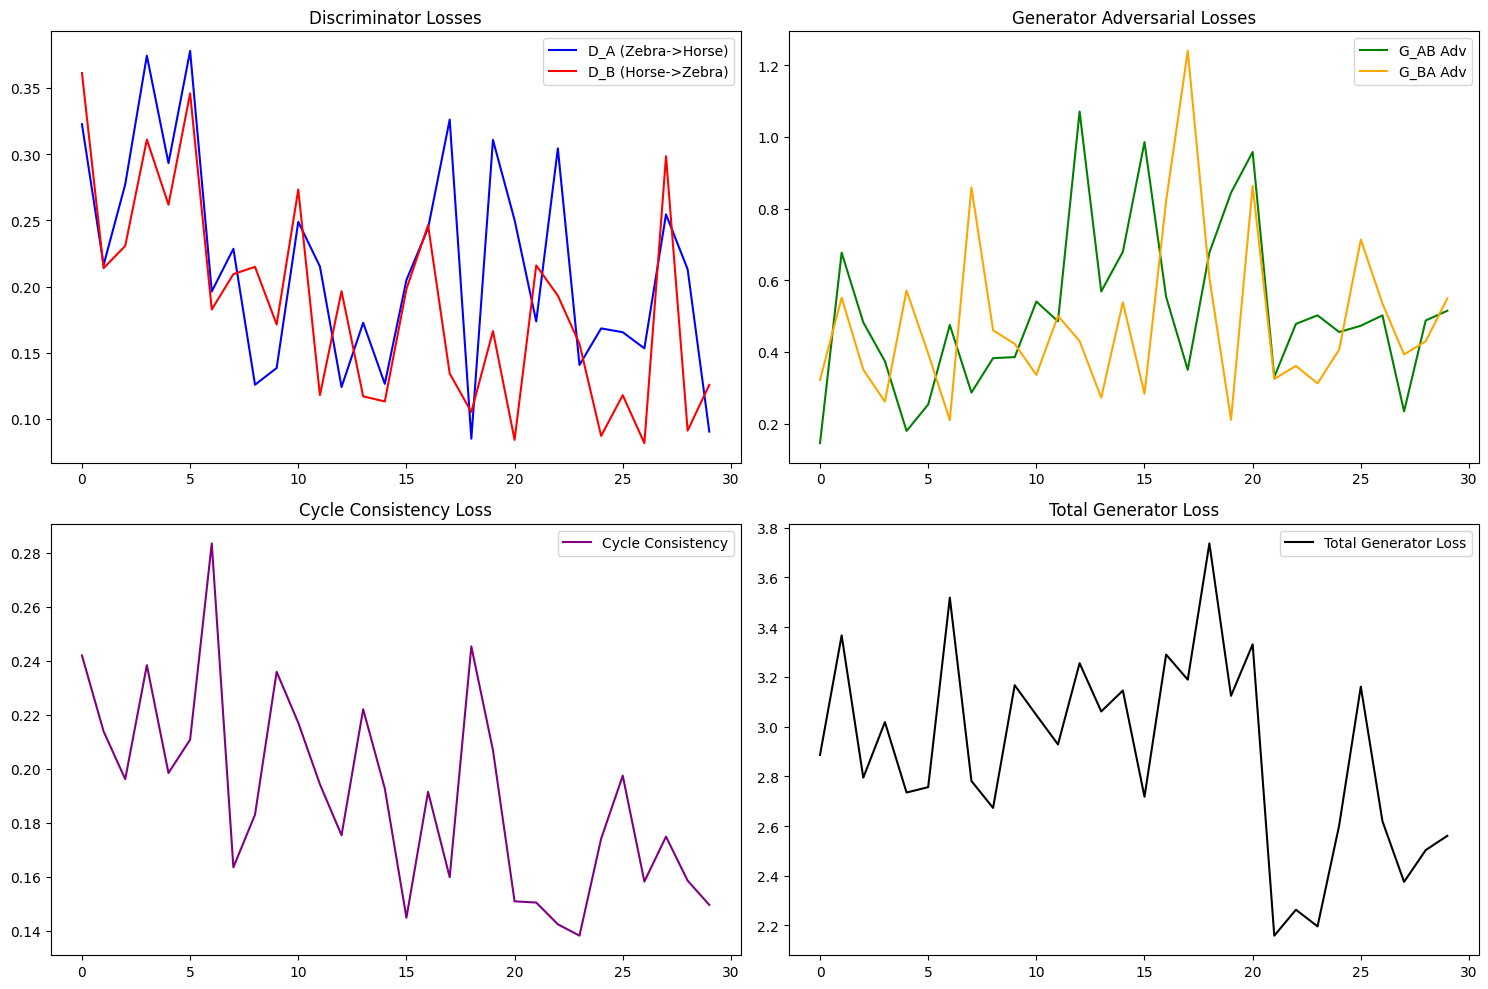

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import glob
import os
import itertools
import time
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------
# 1. Dataset & DataLoader Definition
# You skipped this part, which caused the NameError
# ----------------------------------------
class ImageDataset(Dataset):
    def __init__(self, root, transforms_=None, mode='train'):
        self.transform = transforms_
        self.files_A = sorted(glob.glob(os.path.join(root, '%sA' % mode) + '/*.*'))
        self.files_B = sorted(glob.glob(os.path.join(root, '%sB' % mode) + '/*.*'))

    def __getitem__(self, index):
        # Use modulo to handle unaligned datasets of different sizes
        item_A = self.transform(Image.open(self.files_A[index % len(self.files_A)]).convert('RGB'))
        item_B = self.transform(Image.open(self.files_B[index % len(self.files_B)]).convert('RGB'))
        return {'A': item_A, 'B': item_B}

    def __len__(self):
        return max(len(self.files_A), len(self.files_B))

# Transformations: Resize to 128x128 as requested
transforms_train = transforms.Compose([
    transforms.Resize((128, 128), Image.BICUBIC),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transforms_test = transforms.Compose([
    transforms.Resize((128, 128), Image.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Initialize DataLoaders
# [cite_start]Batch size 1 is standard for CycleGAN [cite: 192]
train_dataloader = DataLoader(
    ImageDataset("horse2zebra", transforms_=transforms_train, mode='train'),
    batch_size=1, shuffle=True, num_workers=2
)

test_dataloader = DataLoader(
    ImageDataset("horse2zebra", transforms_=transforms_test, mode='test'),
    batch_size=1, shuffle=False, num_workers=1
)

# ----------------------------------------
# 2. Model Instantiation
# We need 4 models: 2 Generators and 2 Discriminators
# ----------------------------------------
input_shape = (3, 128, 128)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize models
G_AB = Generator(input_shape, num_residual_blocks=6).to(device) # Horse -> Zebra
G_BA = Generator(input_shape, num_residual_blocks=6).to(device) # Zebra -> Horse
D_A = Discriminator(input_shape).to(device) # Discriminator for Horse
D_B = Discriminator(input_shape).to(device) # Discriminator for Zebra

# [cite_start]Apply weights [cite: 562]
G_AB.apply(weights_init_normal)
G_BA.apply(weights_init_normal)
D_A.apply(weights_init_normal)
D_B.apply(weights_init_normal)

# ----------------------------------------
# 3. Optimizers & Losses
# ----------------------------------------
# [cite_start]Adversarial Loss (MSE) [cite: 186, 188]
criterion_GAN = nn.MSELoss()
# [cite_start]Cycle Loss (L1) [cite: 162]
criterion_cycle = nn.L1Loss()

lr = 0.0002
# [cite_start]Adam Optimizer [cite: 192]
optimizer_G = torch.optim.Adam(
    itertools.chain(G_AB.parameters(), G_BA.parameters()), lr=lr, betas=(0.5, 0.999)
)
optimizer_D_A = torch.optim.Adam(D_A.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D_B = torch.optim.Adam(D_B.parameters(), lr=lr, betas=(0.5, 0.999))

# ----------------------------------------
# 4. Training Loop
# ----------------------------------------
n_epochs = 30
lambda_cyc = 10.0 # [cite: 192]

# Lists to keep track of losses
losses = {'D_A': [], 'D_B': [], 'G_AB_adv': [], 'G_BA_adv': [], 'Cycle': [], 'Total_G': []}

print(f"Starting training for {n_epochs} epochs on {device}...")
start_time = time.time()
Tensor = torch.cuda.FloatTensor if torch.cuda.is_available() else torch.Tensor

for epoch in range(n_epochs):
    for i, batch in enumerate(train_dataloader):

        # Set model input
        real_A = batch['A'].type(Tensor)
        real_B = batch['B'].type(Tensor)

        # Valid/Fake labels
        # PatchGAN output shape: (batch_size, 1, 16, 16) for 128x128 input
        valid = Tensor(np.ones((real_A.size(0), *D_A(real_A).shape[1:])))
        fake = Tensor(np.zeros((real_A.size(0), *D_A(real_A).shape[1:])))

        # ------------------
        #  Train Generators
        # ------------------
        optimizer_G.zero_grad()

        # GAN Loss (A -> B)
        fake_B = G_AB(real_A)
        loss_GAN_AB = criterion_GAN(D_B(fake_B), valid)

        # GAN Loss (B -> A)
        fake_A = G_BA(real_B)
        loss_GAN_BA = criterion_GAN(D_A(fake_A), valid)

        # Cycle Consistency Loss
        rec_A = G_BA(fake_B)
        loss_cycle_A = criterion_cycle(rec_A, real_A)

        rec_B = G_AB(fake_A)
        loss_cycle_B = criterion_cycle(rec_B, real_B)

        loss_cycle = (loss_cycle_A + loss_cycle_B) / 2

        # Total Generator Loss
        loss_G = loss_GAN_AB + loss_GAN_BA + (lambda_cyc * loss_cycle)

        loss_G.backward()
        optimizer_G.step()

        # ----------------------
        #  Train Discriminator A
        # ----------------------
        optimizer_D_A.zero_grad()
        # Real loss
        loss_D_real = criterion_GAN(D_A(real_A), valid)
        # Fake loss (detached)
        loss_D_fake = criterion_GAN(D_A(fake_A.detach()), fake)
        loss_D_A = 0.5 * (loss_D_real + loss_D_fake)
        loss_D_A.backward()
        optimizer_D_A.step()

        # ----------------------
        #  Train Discriminator B
        # ----------------------
        optimizer_D_B.zero_grad()
        # Real loss
        loss_D_real = criterion_GAN(D_B(real_B), valid)
        # Fake loss (detached)
        loss_D_fake = criterion_GAN(D_B(fake_B.detach()), fake)
        loss_D_B = 0.5 * (loss_D_real + loss_D_fake)
        loss_D_B.backward()
        optimizer_D_B.step()

    # Log Progress (Average loss per epoch)
    losses['D_A'].append(loss_D_A.item())
    losses['D_B'].append(loss_D_B.item())
    losses['G_AB_adv'].append(loss_GAN_AB.item())
    losses['G_BA_adv'].append(loss_GAN_BA.item())
    losses['Cycle'].append(loss_cycle.item())
    losses['Total_G'].append(loss_G.item())

    print(f"[Epoch {epoch+1}/{n_epochs}] [G loss: {loss_G.item():.4f}] [Cycle: {loss_cycle.item():.4f}]")

    # ----------------------
    #  Visualization
    # ----------------------
    if (epoch + 1) in [10, 20, 30]:
        print(f"\n--- Samples at Epoch {epoch+1} ---")
        G_AB.eval()
        G_BA.eval()

        # Take a sample from test set
        batch = next(iter(test_dataloader))
        real_A = batch['A'].type(Tensor)
        real_B = batch['B'].type(Tensor)

        fake_B = G_AB(real_A)
        rec_A = G_BA(fake_B)

        fake_A = G_BA(real_B)
        rec_B = G_AB(fake_A)

        # Helper to un-normalize and plot
        def to_img(x):
            x = 0.5 * (x + 1)
            x = x.clamp(0, 1)
            return x.permute(1, 2, 0).cpu().detach().numpy()

        fig, axs = plt.subplots(2, 3, figsize=(10, 7))
        titles = ['Real', 'Translated', 'Reconstructed']

        # A -> B -> A
        row1 = [real_A[0], fake_B[0], rec_A[0]]
        for ax, img, title in zip(axs[0], row1, titles):
            ax.imshow(to_img(img))
            ax.set_title(f'Horse -> Zebra: {title}')
            ax.axis('off')

        # B -> A -> B
        row2 = [real_B[0], fake_A[0], rec_B[0]]
        for ax, img, title in zip(axs[1], row2, titles):
            ax.imshow(to_img(img))
            ax.set_title(f'Zebra -> Horse: {title}')
            ax.axis('off')

        plt.show()
        G_AB.train()
        G_BA.train()

print(f"Training finished in {(time.time() - start_time)/60:.1f} minutes.")

# ----------------------------------------
# 5. Plotting Loss Curves
# ----------------------------------------
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(losses['D_A'], label='D_A (Zebra->Horse)', color='blue')
plt.plot(losses['D_B'], label='D_B (Horse->Zebra)', color='red')
plt.title('Discriminator Losses')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(losses['G_AB_adv'], label='G_AB Adv', color='green')
plt.plot(losses['G_BA_adv'], label='G_BA Adv', color='orange')
plt.title('Generator Adversarial Losses')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(losses['Cycle'], label='Cycle Consistency', color='purple')
plt.title('Cycle Consistency Loss')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(losses['Total_G'], label='Total Generator Loss', color='black')
plt.title('Total Generator Loss')
plt.legend()

plt.tight_layout()
plt.show()

## 6. Main Training Results

During training, the adversarial, cycle-consistency, and discriminator losses are recorded for each epoch.

The generated samples are also visualized at epochs **10, 20, and 30**.

For each visualization, both translation directions are shown:

$$
\text{Horse} \rightarrow \text{Zebra} \rightarrow \text{Horse}
$$

and

$$
\text{Zebra} \rightarrow \text{Horse} \rightarrow \text{Zebra}
$$

These reconstructions provide a qualitative way to examine whether the model learns the desired domain translation while preserving the underlying structure of the input images.


## 7. Training Loss Analysis

The training curves show the evolution of the discriminator losses, generator adversarial losses, cycle-consistency loss, and total generator loss throughout training.

Because CycleGAN is trained through an adversarial optimization process, the losses are not expected to decrease monotonically. Instead, the curves provide an overview of the interaction between the generators and discriminators and the stability of the training process.

The generated images and cycle reconstructions are therefore considered alongside the loss curves when evaluating the quality of the learned translation.


# 8. Additional Experiment: Monet2Photo

To investigate the effect of additional stabilization and regularization techniques, a second CycleGAN experiment is performed using the **Monet2Photo** dataset.

This experiment is separate from the main Horse2Zebra training. It uses the same CycleGAN framework but introduces two additional components:

* **Identity loss**
* **Replay buffer for generated images**

The purpose of this experiment is to examine how these components affect the training behavior and generated results.


for details.

--2025-11-27 18:39:21--  https://efrosgans.eecs.berkeley.edu/cyclegan/datasets/monet2photo.zip
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 305231073 (291M) [application/zip]
Saving to: ‘monet2photo.zip’

monet2photo.zip     100%[===================>] 291.09M  32.2MB/s    in 9.5s    

2025-11-27 18:39:31 (30.7 MB/s) - ‘monet2photo.zip’ saved [305231073/305231073]

Dataset folder already exists. Skipping extraction.
------------------------------
Visualizing Domain A: Monet Paintings


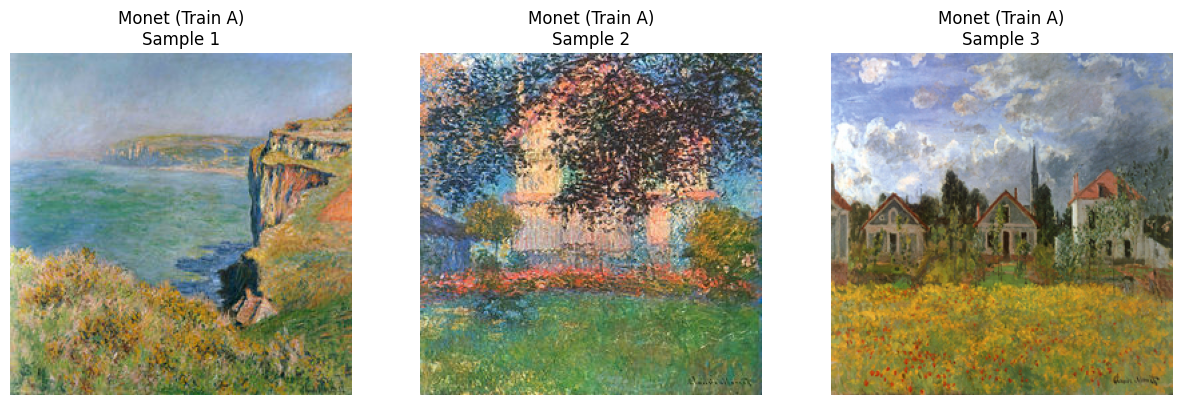

------------------------------
Visualizing Domain B: Real Photos


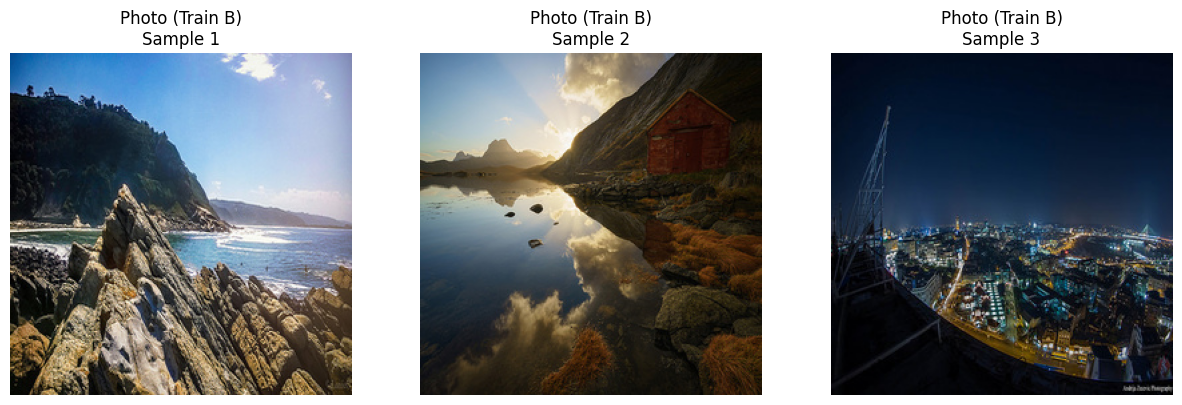

In [2]:
import os
import zipfile
import random
import matplotlib.pyplot as plt
from PIL import Image

# ---------------------------------------------------------
# 1. Download the Monet2Photo dataset
# ---------------------------------------------------------
dataset_url = "https://efrosgans.eecs.berkeley.edu/cyclegan/datasets/monet2photo.zip"
zip_filename = "monet2photo.zip"

print(f"Downloading {zip_filename} from {dataset_url}...")
# -O forces the output filename to be monet2photo.zip
!wget -N {dataset_url} -O {zip_filename}

# ---------------------------------------------------------
# 2. Unzip the dataset
# ---------------------------------------------------------
# The dataset extracts into a folder named 'monet2photo'
if not os.path.exists("monet2photo"):
    print(f"Extracting {zip_filename}...")
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Extraction complete.")
else:
    print("Dataset folder already exists. Skipping extraction.")

# ---------------------------------------------------------
# 3. Setup directory paths
# ---------------------------------------------------------
base_path = "monet2photo"
train_a_path = os.path.join(base_path, "trainA") # Monet Paintings
train_b_path = os.path.join(base_path, "trainB") # Real Photos

# Verify directories exist
if not os.path.exists(train_a_path) or not os.path.exists(train_b_path):
    print(f"Error: Could not find trainA or trainB inside {base_path}")
    if os.path.exists(base_path):
        print(f"Contents of {base_path}: {os.listdir(base_path)}")
    else:
        print(f"Folder {base_path} not found.")
else:
    # ---------------------------------------------------------
    # 4. Function to visualize random samples
    # ---------------------------------------------------------
    def visualize_samples(directory_path, domain_name, num_samples=3):
        all_files = os.listdir(directory_path)
        # Filter for image extensions
        image_files = [f for f in all_files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if len(image_files) < num_samples:
            print(f"Not enough images in {domain_name} to sample {num_samples}.")
            return

        selected_files = random.sample(image_files, num_samples)

        plt.figure(figsize=(15, 5))
        for i, file_name in enumerate(selected_files):
            img_path = os.path.join(directory_path, file_name)
            img = Image.open(img_path)

            plt.subplot(1, num_samples, i + 1)
            plt.imshow(img)
            plt.title(f"{domain_name}\nSample {i+1}")
            plt.axis("off")
        plt.show()

    # ---------------------------------------------------------
    # 5. Display images
    # ---------------------------------------------------------
    print("-" * 30)
    print("Visualizing Domain A: Monet Paintings")
    visualize_samples(train_a_path, "Monet (Train A)")

    print("-" * 30)
    print("Visualizing Domain B: Real Photos")
    visualize_samples(train_b_path, "Photo (Train B)")

## 8.1 Monet2Photo Dataset

The **Monet2Photo** dataset contains two unpaired domains:

* **Domain A:** Monet paintings
* **Domain B:** Real photographs

As in the Horse2Zebra experiment, the two domains are not paired. The model therefore learns the translation between the domains using adversarial and cycle-consistency objectives rather than corresponding image pairs.

The images are resized to **128 × 128** pixels and normalized using the same preprocessing pipeline as the previous experiment.


## 8.2 Replay Buffer

A **replay buffer** is introduced in this experiment to stabilize discriminator training.

Instead of training the discriminators only on the most recently generated fake images, the buffer stores previously generated samples and occasionally reuses them when updating the discriminators.

The implementation uses two separate buffers:

* One for generated Monet images
* One for generated photo images

Each buffer has a maximum capacity of **50 images**.

This provides the discriminators with a more diverse history of generated samples and reduces their dependence on the latest generator outputs.


## 8.3 Identity Loss

The second experiment also introduces an **identity loss**.

Identity loss encourages each generator to preserve an image when the image is already in the target domain.

For an image \(x\) from domain A:

$$
G_{BA}(x) \approx x
$$

For an image \(y\) from domain B:

$$
G_{AB}(y) \approx y
$$

The identity loss used in the training loop is:

$$
\mathcal{L}_{identity}
=
\lambda_{id}
\left(
\|G_{BA}(x)-x\|_1
+
\|G_{AB}(y)-y\|_1
\right)
$$

In this experiment:

$$
\lambda_{id}=5
$$

Identity loss encourages the generators to avoid unnecessary changes to images that are already compatible with the target domain and can help preserve important visual characteristics such as color composition.


## 8.4 Optimized Training with Identity Loss and Replay Buffer

The Monet2Photo experiment uses an optimized version of the CycleGAN training loop.

Compared with the previous Horse2Zebra experiment, the following components are added:

* Identity loss
* Replay buffers for generated images
* Mixed-precision training

The generator loss now contains three components:

$$
\mathcal{L}_G =
\mathcal{L}_{GAN}
+
\mathcal{L}_{cycle}
+
\mathcal{L}_{identity}
$$

The cycle-consistency term is weighted by \(\lambda_{cyc}=10\), while the identity term uses \(\lambda_{id}=5\).

The replay buffers are used when computing the fake-image losses of the discriminators, allowing them to train on both recent and previously generated samples.

Mixed-precision training is used to reduce GPU memory usage and improve computational efficiency.


## 8.5 Monet2Photo Training Results

The optimized CycleGAN is trained on the Monet2Photo dataset for **20 epochs** using a batch size of **4** and a learning rate of **0.0002**.

Generated samples are visualized at epochs **5, 10, and 20** in both translation directions:

$$
\text{Monet} \rightarrow \text{Photo} \rightarrow \text{Monet}
$$

and

$$
\text{Photo} \rightarrow \text{Monet} \rightarrow \text{Photo}
$$

These results are used to qualitatively examine the effect of the additional identity-loss and replay-buffer components on the learned translations and cycle reconstructions.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Starting Optimized CycleGAN Training for 20 epochs...
[Epoch 1/20] [Batch 1500] [G loss: 7.014]
Time for Epoch 1: 292.5 sec
[Epoch 2/20] [Batch 1500] [G loss: 6.466]
Time for Epoch 2: 274.3 sec
[Epoch 3/20] [Batch 1500] [G loss: 5.470]
Time for Epoch 3: 274.4 sec
[Epoch 4/20] [Batch 1500] [G loss: 4.855]
Time for Epoch 4: 274.3 sec
[Epoch 5/20] [Batch 1500] [G loss: 5.882]
Time for Epoch 5: 274.6 sec

--- Samples at Epoch 5 ---


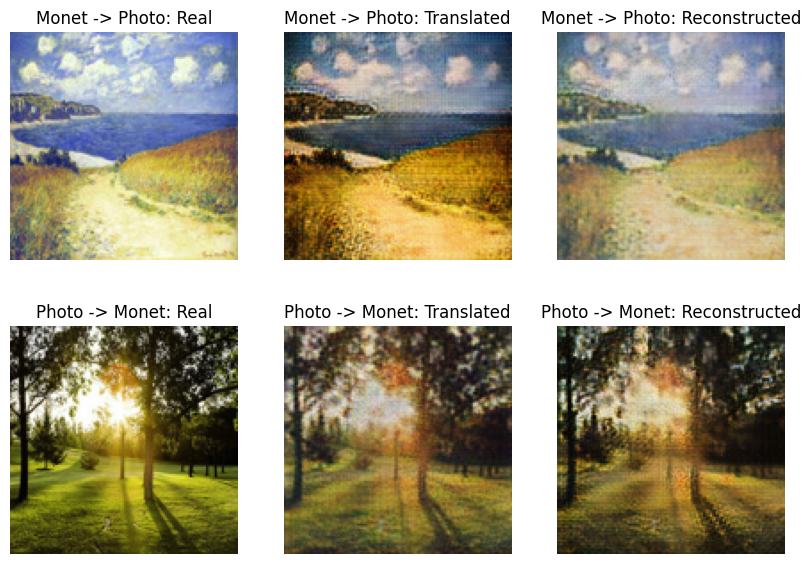

[Epoch 6/20] [Batch 1500] [G loss: 6.533]
Time for Epoch 6: 274.7 sec
[Epoch 7/20] [Batch 1500] [G loss: 5.413]
Time for Epoch 7: 274.5 sec
[Epoch 8/20] [Batch 1500] [G loss: 5.928]
Time for Epoch 8: 274.3 sec
[Epoch 9/20] [Batch 1500] [G loss: 4.288]
Time for Epoch 9: 274.1 sec
[Epoch 10/20] [Batch 1500] [G loss: 4.451]
Time for Epoch 10: 274.1 sec

--- Samples at Epoch 10 ---


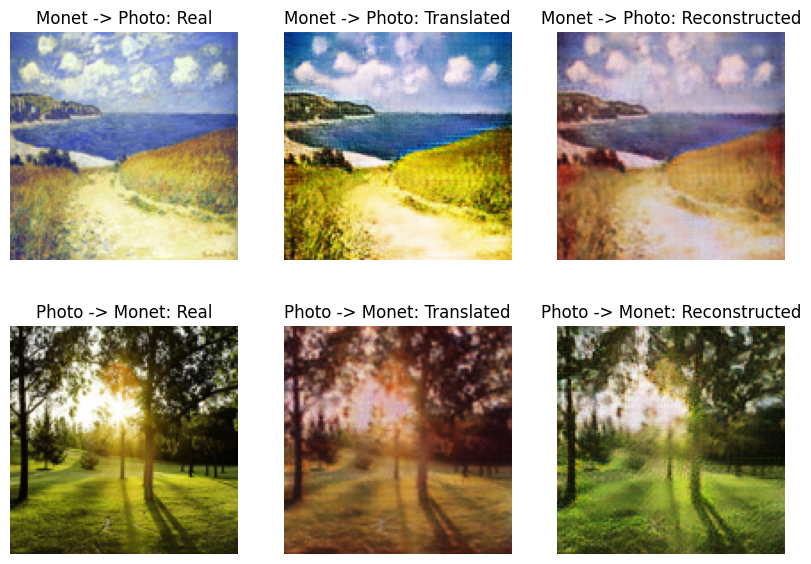

[Epoch 11/20] [Batch 1500] [G loss: 5.607]
Time for Epoch 11: 274.1 sec
[Epoch 12/20] [Batch 1500] [G loss: 4.253]
Time for Epoch 12: 274.1 sec
[Epoch 13/20] [Batch 1500] [G loss: 5.302]
Time for Epoch 13: 273.8 sec
[Epoch 14/20] [Batch 1500] [G loss: 5.323]
Time for Epoch 14: 274.1 sec
[Epoch 15/20] [Batch 1500] [G loss: 5.424]
Time for Epoch 15: 274.9 sec
[Epoch 16/20] [Batch 1500] [G loss: 4.931]
Time for Epoch 16: 274.8 sec
[Epoch 17/20] [Batch 1500] [G loss: 3.996]
Time for Epoch 17: 274.0 sec
[Epoch 18/20] [Batch 1500] [G loss: 3.951]
Time for Epoch 18: 274.5 sec
[Epoch 19/20] [Batch 1500] [G loss: 4.554]
Time for Epoch 19: 274.4 sec
[Epoch 20/20] [Batch 1500] [G loss: 4.036]
Time for Epoch 20: 274.4 sec

--- Samples at Epoch 20 ---


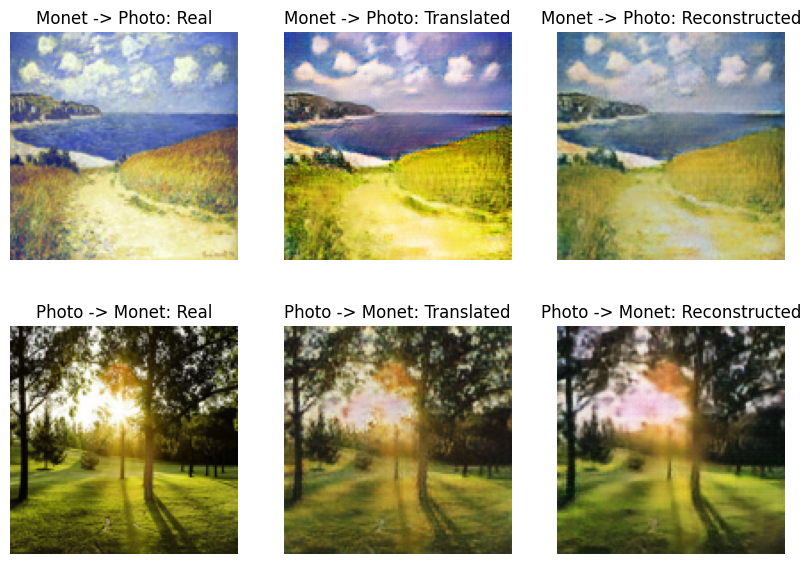

Total Training Time: 91.8 minutes.


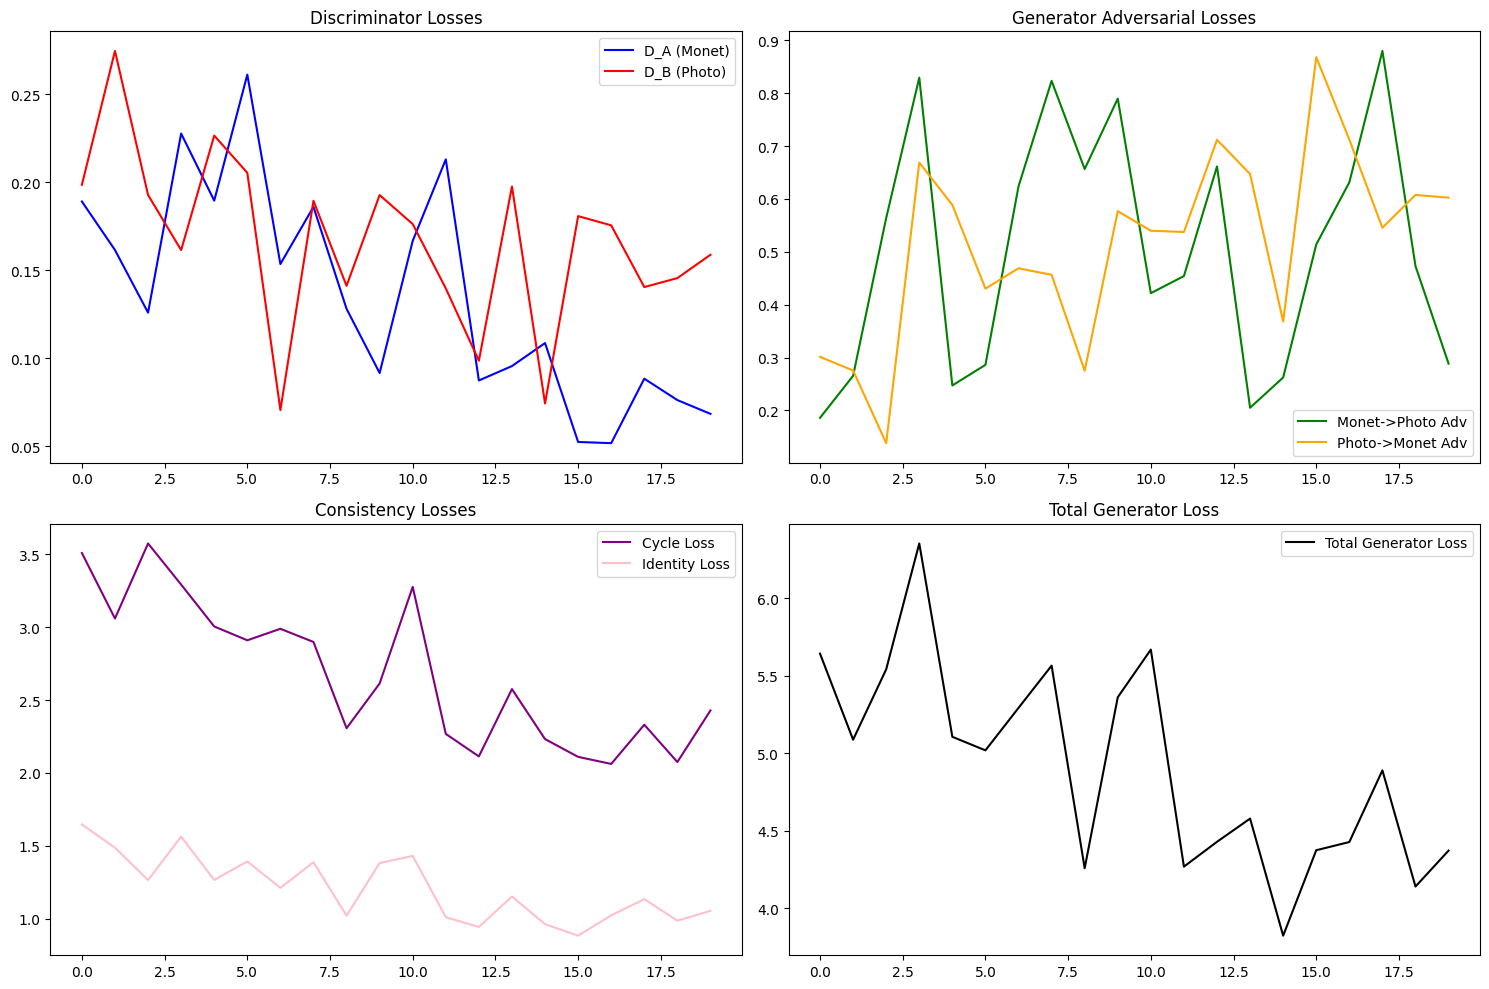

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import glob
import os
import itertools
import time
import random
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------
# 0. Optimized Tensor-Based Replay Buffer
# ----------------------------------------
class FastReplayBuffer:
    def __init__(self, max_size=50, input_shape=(3, 128, 128), device='cuda'):
        self.max_size = max_size
        self.device = device
        self.curr_size = 0
        # Pre-allocate memory on GPU
        self.buffer = torch.empty((max_size, *input_shape), dtype=torch.float32, device=device)

    def push_and_pop(self, data):
        to_return = []
        data = data.detach()
        batch_size = data.shape[0]

        for i in range(batch_size):
            element = data[i].unsqueeze(0)
            if self.curr_size < self.max_size:
                self.buffer[self.curr_size] = data[i]
                self.curr_size += 1
                to_return.append(element)
            else:
                if random.uniform(0, 1) > 0.5:
                    rand_idx = random.randint(0, self.max_size - 1)
                    to_return.append(self.buffer[rand_idx].unsqueeze(0).clone())
                    self.buffer[rand_idx] = data[i]
                else:
                    to_return.append(element)
        return torch.cat(to_return).to(self.device)

# ----------------------------------------
# 1. Configuration & Dataset
# ----------------------------------------
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_shape = (3, 128, 128)
n_epochs = 20
batch_size = 4
lr = 0.0002
lambda_cyc = 10.0
lambda_id = 0.5 * lambda_cyc

class ImageDataset(Dataset):
    def __init__(self, root, transforms_=None, mode='train'):
        self.transform = transforms_
        self.files_A = sorted(glob.glob(os.path.join(root, '%sA' % mode) + '/*.*'))
        self.files_B = sorted(glob.glob(os.path.join(root, '%sB' % mode) + '/*.*'))

    def __getitem__(self, index):
        item_A = self.transform(Image.open(self.files_A[index % len(self.files_A)]).convert('RGB'))
        item_B = self.transform(Image.open(self.files_B[index % len(self.files_B)]).convert('RGB'))
        return {'A': item_A, 'B': item_B}

    def __len__(self):
        return max(len(self.files_A), len(self.files_B))

transforms_train = transforms.Compose([
    transforms.Resize((128, 128), Image.BICUBIC),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transforms_test = transforms.Compose([
    transforms.Resize((128, 128), Image.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataloader = DataLoader(
    ImageDataset("monet2photo", transforms_=transforms_train, mode='train'),
    batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True
)

test_dataloader = DataLoader(
    ImageDataset("monet2photo", transforms_=transforms_test, mode='test'),
    batch_size=1, shuffle=False, num_workers=1, pin_memory=True
)

# ----------------------------------------
# 2. Models & Optimization Setup
# ----------------------------------------
G_AB = Generator(input_shape, num_residual_blocks=6).to(device)
G_BA = Generator(input_shape, num_residual_blocks=6).to(device)
D_A = Discriminator(input_shape).to(device)
D_B = Discriminator(input_shape).to(device)

def weights_init_normal(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        torch.nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm2d") != -1:
        torch.nn.init.normal_(m.weight.data, 1.0, 0.02)
        torch.nn.init.constant_(m.bias.data, 0.0)

G_AB.apply(weights_init_normal)
G_BA.apply(weights_init_normal)
D_A.apply(weights_init_normal)
D_B.apply(weights_init_normal)

criterion_GAN = nn.MSELoss()
criterion_cycle = nn.L1Loss()
criterion_identity = nn.L1Loss()

optimizer_G = torch.optim.Adam(itertools.chain(G_AB.parameters(), G_BA.parameters()), lr=lr, betas=(0.5, 0.999))
optimizer_D_A = torch.optim.Adam(D_A.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D_B = torch.optim.Adam(D_B.parameters(), lr=lr, betas=(0.5, 0.999))

fake_A_buffer = FastReplayBuffer(max_size=50, input_shape=input_shape, device=device)
fake_B_buffer = FastReplayBuffer(max_size=50, input_shape=input_shape, device=device)

scaler = torch.amp.GradScaler('cuda')

# ----------------------------------------
# 3. Optimized Training Loop
# ----------------------------------------
# Lists to keep track of losses (Exact structure you requested)
losses = {'D_A': [], 'D_B': [], 'G_AB_adv': [], 'G_BA_adv': [], 'Cycle': [], 'Identity': [], 'Total_G': []}

print(f"Starting Optimized CycleGAN Training for {n_epochs} epochs...")
start_time = time.time()

for epoch in range(n_epochs):
    epoch_start = time.time()
    for i, batch in enumerate(train_dataloader):

        real_A = batch['A'].to(device, non_blocking=True)
        real_B = batch['B'].to(device, non_blocking=True)

        valid = torch.ones((real_A.size(0), *D_A(real_A).shape[1:]), device=device)
        fake = torch.zeros((real_A.size(0), *D_A(real_A).shape[1:]), device=device)

        # ------------------
        #  Train Generators
        # ------------------
        optimizer_G.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda'):
            # Identity Loss
            loss_id_A = criterion_identity(G_BA(real_A), real_A)
            loss_id_B = criterion_identity(G_AB(real_B), real_B)
            loss_identity = (loss_id_A + loss_id_B) * lambda_id

            # GAN Loss
            fake_B = G_AB(real_A)
            loss_GAN_AB = criterion_GAN(D_B(fake_B), valid)
            fake_A = G_BA(real_B)
            loss_GAN_BA = criterion_GAN(D_A(fake_A), valid)

            # Cycle Loss
            rec_A = G_BA(fake_B)
            loss_cycle_A = criterion_cycle(rec_A, real_A)
            rec_B = G_AB(fake_A)
            loss_cycle_B = criterion_cycle(rec_B, real_B)
            loss_cycle = (loss_cycle_A + loss_cycle_B) * lambda_cyc

            # Total Loss
            loss_G = loss_GAN_AB + loss_GAN_BA + loss_cycle + loss_identity

        scaler.scale(loss_G).backward()
        scaler.step(optimizer_G)
        scaler.update()

        # ----------------------
        #  Train Discriminators
        # ----------------------
        optimizer_D_A.zero_grad(set_to_none=True)
        optimizer_D_B.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda'):
            # D_A
            loss_D_real_A = criterion_GAN(D_A(real_A), valid)
            fake_A_ = fake_A_buffer.push_and_pop(fake_A)
            loss_D_fake_A = criterion_GAN(D_A(fake_A_), fake)
            loss_D_A = (loss_D_real_A + loss_D_fake_A) * 0.5

            # D_B
            loss_D_real_B = criterion_GAN(D_B(real_B), valid)
            fake_B_ = fake_B_buffer.push_and_pop(fake_B)
            loss_D_fake_B = criterion_GAN(D_B(fake_B_), fake)
            loss_D_B = (loss_D_real_B + loss_D_fake_B) * 0.5

        scaler.scale(loss_D_A).backward()
        scaler.step(optimizer_D_A)

        scaler.scale(loss_D_B).backward()
        scaler.step(optimizer_D_B)
        scaler.update()

        if i % 100 == 0:
            print(f"\r[Epoch {epoch+1}/{n_epochs}] [Batch {i}] [G loss: {loss_G.item():.3f}]", end='')

    # --- Append Losses at the END of Epoch (Like your target code) ---
    # We take the value from the LAST batch of the epoch to avoid slowing down the loop
    losses['D_A'].append(loss_D_A.item())
    losses['D_B'].append(loss_D_B.item())
    losses['G_AB_adv'].append(loss_GAN_AB.item())
    losses['G_BA_adv'].append(loss_GAN_BA.item())
    losses['Cycle'].append(loss_cycle.item())
    losses['Identity'].append(loss_identity.item())
    losses['Total_G'].append(loss_G.item())

    print(f"\nTime for Epoch {epoch+1}: {(time.time() - epoch_start):.1f} sec")

    # ----------------------
    #  Visualization
    # ----------------------
    if (epoch + 1) in [5, 10, 20]:
        print(f"\n--- Samples at Epoch {epoch+1} ---")
        G_AB.eval()
        G_BA.eval()
        with torch.no_grad():
            batch = next(iter(test_dataloader))
            real_A = batch['A'].to(device)
            real_B = batch['B'].to(device)
            fake_B = G_AB(real_A)
            fake_A = G_BA(real_B)
            rec_A = G_BA(fake_B)
            rec_B = G_AB(fake_A)

        def to_img(x): return 0.5 * (x.permute(1, 2, 0).cpu().numpy() + 1)

        fig, axs = plt.subplots(2, 3, figsize=(10, 7))
        titles = ['Real', 'Translated', 'Reconstructed']
        # Row 1: Monet -> Photo -> Monet
        row1 = [real_A[0], fake_B[0], rec_A[0]]
        for ax, img, title in zip(axs[0], row1, titles):
            ax.imshow(to_img(img))
            ax.set_title(f'Monet -> Photo: {title}')
            ax.axis('off')

        # Row 2: Photo -> Monet -> Photo
        row2 = [real_B[0], fake_A[0], rec_B[0]]
        for ax, img, title in zip(axs[1], row2, titles):
            ax.imshow(to_img(img))
            ax.set_title(f'Photo -> Monet: {title}')
            ax.axis('off')
        plt.show()

        G_AB.train()
        G_BA.train()

print(f"Total Training Time: {(time.time() - start_time)/60:.1f} minutes.")

# ----------------------------------------
# 4. Plotting Loss Curves
# ----------------------------------------
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(losses['D_A'], label='D_A (Monet)', color='blue')
plt.plot(losses['D_B'], label='D_B (Photo)', color='red')
plt.title('Discriminator Losses')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(losses['G_AB_adv'], label='Monet->Photo Adv', color='green')
plt.plot(losses['G_BA_adv'], label='Photo->Monet Adv', color='orange')
plt.title('Generator Adversarial Losses')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(losses['Cycle'], label='Cycle Loss', color='purple')
plt.plot(losses['Identity'], label='Identity Loss', color='pink') # Added Identity here for completeness
plt.title('Consistency Losses')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(losses['Total_G'], label='Total Generator Loss', color='black')
plt.title('Total Generator Loss')
plt.legend()

plt.tight_layout()
plt.show()

## 9. Comparison of the Two Experiments

The notebook contains two separate CycleGAN experiments.

The first experiment uses **Horse2Zebra** as the main training task and follows the basic CycleGAN objective based on adversarial and cycle-consistency losses.

The second experiment uses **Monet2Photo** to investigate additional training components, specifically **identity loss** and a **replay buffer**. The second experiment also uses mixed-precision training and a larger batch size as part of the optimized implementation.

The two experiments serve different purposes: the Horse2Zebra experiment demonstrates the main CycleGAN training pipeline, while the Monet2Photo experiment provides an additional investigation of techniques that can influence training stability and image preservation.
